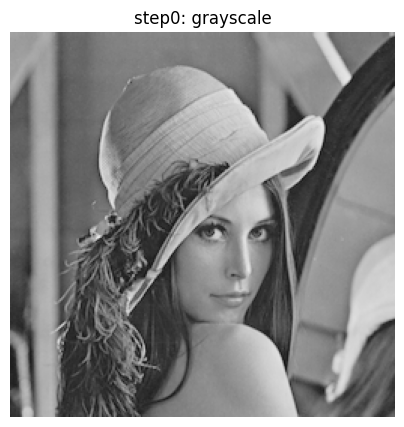

In [40]:
import numpy as np 
from PIL import Image 
import matplotlib.pyplot as plt 
import seaborn as sns

img = Image.open("Lenna.png").convert("L") # L = grayscale 
x = np.array(img, dtype=np.float32) / 255.0 # значения в [0, 1] 
plt.figure(figsize=(5, 5))
plt.imshow(x, cmap="gray", vmin=0, vmax=1) 
plt.axis("off") 
plt.title("step0: grayscale") 
plt.show() 

In [5]:
x.shape

(256, 256)

In [22]:
test = np.array([
    [1, 2, 3, 4, 5],
    [6, 7, 8, 9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
])

np.pad(test, 1, mode='edge')

array([[ 1,  1,  2,  3,  4,  5,  5],
       [ 1,  1,  2,  3,  4,  5,  5],
       [ 6,  6,  7,  8,  9, 10, 10],
       [11, 11, 12, 13, 14, 15, 15],
       [16, 16, 17, 18, 19, 20, 20],
       [21, 21, 22, 23, 24, 25, 25],
       [21, 21, 22, 23, 24, 25, 25]])

In [30]:
def conv2d(x: np.ndarray, k: np.ndarray) -> np.ndarray: 
    pad_x = np.pad(x, k.shape[0] - 2, mode='edge')
    res = np.zeros(x.shape)

    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            cur = pad_x[i:i+k.shape[0], j:j+k.shape[1]]
            res[i][j] = (cur * k).sum()

    return res

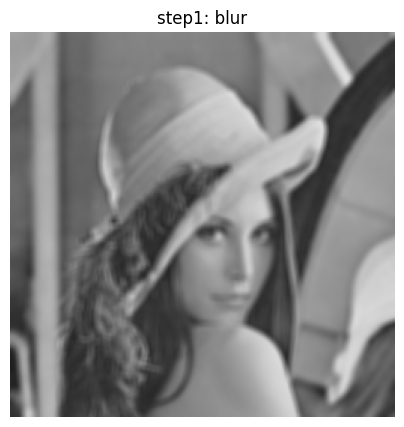

In [31]:
k_blur = np.ones((5, 5), dtype=np.float32) / 25.0 

y = conv2d(x, k_blur) 
y = np.clip(y, 0, 1) 
plt.figure(figsize=(5, 5)) 
plt.imshow(y, cmap="gray", vmin=0, vmax=1) 
plt.axis("off") 
plt.title("step1: blur") 
plt.show() 

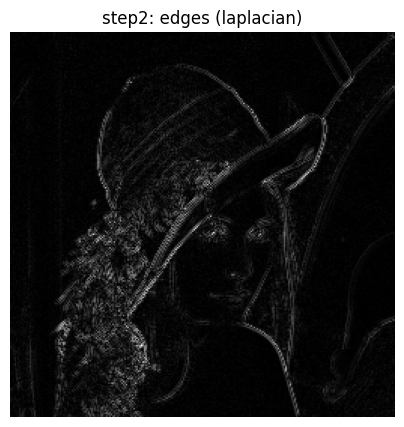

In [33]:
k_lap = np.array([ [0, 1, 0], [1, -4, 1], [0, 1, 0] ], dtype=np.float32) 
e = np.abs(conv2d(x, k_lap)) 
e = e / (e.max() + 1e-8) 
plt.figure(figsize=(5, 5)) 
plt.imshow(e, cmap="gray", vmin=0, vmax=1) 
plt.axis("off") 
plt.title("step2: edges (laplacian)") 
plt.show() 

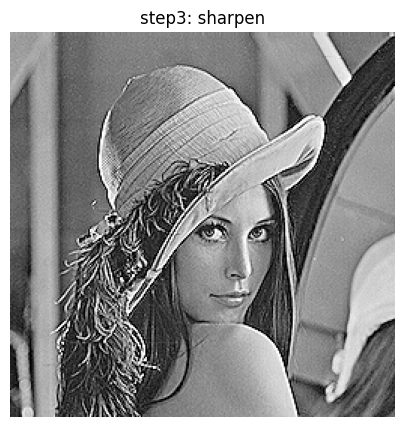

In [34]:
k_sharp = np.array([ [0, -1, 0], [-1, 5, -1], [0, -1, 0] ], dtype=np.float32)
s = conv2d(x, k_sharp)
s = np.clip(s, 0, 1)
plt.figure(figsize=(5, 5)) 
plt.imshow(s, cmap="gray", vmin=0, vmax=1) 
plt.axis("off") 
plt.title("step3: sharpen") 
plt.show() 

---

<Axes: >

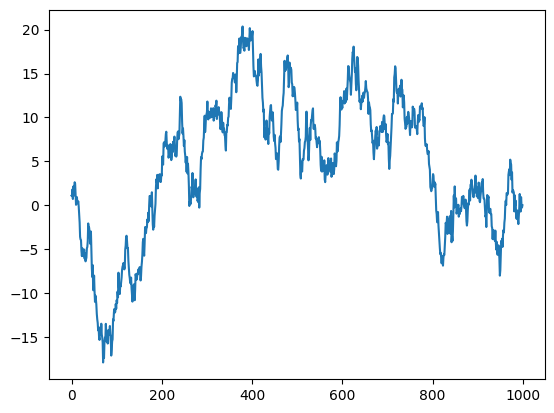

In [ ]:
f = np.cumsum(np.random.normal(size=1000))
f = f - f[-1] * np.linspace(0, 1, 1000)

def func(f, k):
    l = np.zeros(f.shape[0], float)

    

sns.lineplot(f)

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

blurred_img = np.load('blurred.npy')

k_size = 5
kernel = np.ones((k_size, k_size)) / (k_size * k_size)

def deblur_channel(blurred_channel, kernel):
    height, width = blurred_channel.shape
    N = height * width
    
    # ВАШ КОД
        
    return b.reshape((height, width))


recovered_img = np.zeros_like(blurred_img)

for i in range(3):
    print(f"Обработка канала {i+1}/3...")
    recovered_img[:, :, i] = deblur_channel(blurred_img[:, :, i], kernel)

recovered_img = np.clip(recovered_img, 0, 1)

# Рисуем сравнение
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(blurred_img)
ax1.set_title("Вход")
ax1.axis('off')
ax2.imshow(recovered_img)
ax2.set_title("Восстановленная картинка")
ax2.axis('off')
plt.show()

Обработка канала 1/3...


LinAlgError: Singular matrix